In [1]:
import polars as pl
import pandas as pd
from pathlib import Path
import os
import argparse
import numpy as np
import polars as pl
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
def plot_runtime_vs_num_nodes(df: pl.DataFrame, algorithm: str):
    """
    Generates a scatter plot of runtime vs. number of nodes,
    filtered for the 'MULTIFLOW' algorithm.

    The plot uses:
    - x-axis: runtime
    - y-axis: num_nodes
    - color: varies by closed_edge_density
    - marker style: varies by status

    Args:
        df (pl.DataFrame): DataFrame containing the analysis results.
                           Must include 'algorithm', 'runtime', 'num_nodes',
                           'num_closed_edges', and 'status' columns.
    """
    # 1. Filter for the 'MULTIFLOW' algorithm
    plot_df = df.filter(pl.col("algorithm") == algorithm)

    if plot_df.is_empty():
        print("No data found for 'MULTIFLOW' algorithm. Cannot generate plot.")
        return
    plot_df = plot_df.filter(~((pl.col("group_id") == "n40") & (pl.col("num_nodes") <= 40)))


    plot_df = plot_df.with_columns([
        pl.when(pl.col("sum_time")==0)
        .then(pl.col("solve_time"))
        .otherwise(pl.col("sum_time"))
        .alias("runtime")
    ]).with_columns([
        pl.when(pl.col("runtime").is_nan())
        .then(18000)
        .otherwise(pl.col("runtime"))
        .alias("runtime")
    ])

    # --- Add Jitter to Data for Better Visualization ---
    # To prevent points from overlapping in dense clusters, we add a small
    # amount of random noise ("jitter") to their positions.
    num_rows = len(plot_df)
    x_range = plot_df["runtime"].max() - plot_df["runtime"].min()
    y_range = plot_df["num_nodes"].max() - plot_df["num_nodes"].min()

    # Set jitter strength as a small fraction of the data range (e.g., 2%).
    # Use a conditional to avoid errors if all data points are the same.
    x_jitter = x_range * 0.02 if x_range is not None and x_range > 0 else 0
    y_jitter = y_range * 0.02 if y_range is not None and y_range > 0 else 0

    # Create new jittered columns in a new DataFrame for plotting.
    # The original data remains unchanged.
    plot_df_jittered = plot_df.with_columns([
        (pl.col("runtime") + np.random.uniform(-x_jitter, x_jitter, size=num_rows)).alias("runtime_jittered"),
        (pl.col("num_nodes") + np.random.uniform(-y_jitter, y_jitter, size=num_rows)).alias("num_nodes_jittered")
    ])

    print("Data to be plotted (with jitter):")
    print(plot_df_jittered)    

    # 3. Create the scatter plot using seaborn
    plt.figure(figsize=(12, 8))
    sns.set_theme(style="whitegrid")

    scatter_plot = sns.scatterplot(
        data=plot_df_jittered,
        x="runtime_jittered",
        y="num_nodes_jittered",
        hue="closed_edge_density",      # Color points by density
        style="status",       # Change marker shape by status
        palette="Paired",  # A nice color map for continuous data
        s=50,                # Increase marker size for better visibility
        alpha=0.8             # Add some transparency to complement the jitter
    )

    # 4. Customize the plot
    scatter_plot.set_title("Runtime vs. Closed Edge Density for MULTIFLOW Algorithm", fontsize=16, weight='bold')
    scatter_plot.set_xlabel("Runtime (s)", fontsize=12)
    scatter_plot.set_ylabel("Number of nodes", fontsize=12)
    plt.legend(title="Legend", bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()

    # 5. Show the plot
    plt.show()


def plot_runtime_vs_density(df: pl.DataFrame, algorithm: str):
    """
    Generates a scatter plot of runtime vs. closed edge density,
    filtered for the 'MULTIFLOW' algorithm.

    The plot uses:
    - x-axis: runtime
    - y-axis: closed_edge_density
    - color: varies by num_nodes
    - marker style: varies by status

    Args:
        df (pl.DataFrame): DataFrame containing the analysis results.
                           Must include 'algorithm', 'runtime', 'num_nodes',
                           'num_closed_edges', and 'status' columns.
    """
    # 1. Filter for the 'MULTIFLOW' algorithm
    plot_df = df.filter(pl.col("algorithm") == algorithm)

    if plot_df.is_empty():
        print("No data found for 'MULTIFLOW' algorithm. Cannot generate plot.")
        return
    plot_df = plot_df.filter(~((pl.col("group_id") == "n40") & (pl.col("num_nodes") <= 40)))


    plot_df = plot_df.with_columns([
        pl.when(pl.col("sum_time")==0)
        .then(pl.col("solve_time"))
        .otherwise(pl.col("sum_time"))
        .alias("runtime")
    ]).with_columns([
        pl.when(pl.col("runtime").is_nan())
        .then(18000)
        .otherwise(pl.col("runtime"))
        .alias("runtime")
    ])

    # --- Add Jitter to Data for Better Visualization ---
    # To prevent points from overlapping in dense clusters, we add a small
    # amount of random noise ("jitter") to their positions.
    num_rows = len(plot_df)
    x_range = plot_df["runtime"].max() - plot_df["runtime"].min()
    y_range = plot_df["closed_edge_density"].max() - plot_df["closed_edge_density"].min()

    # Set jitter strength as a small fraction of the data range (e.g., 2%).
    # Use a conditional to avoid errors if all data points are the same.
    x_jitter = x_range * 0.02 if x_range is not None and x_range > 0 else 0
    y_jitter = y_range * 0.02 if y_range is not None and y_range > 0 else 0

    # Create new jittered columns in a new DataFrame for plotting.
    # The original data remains unchanged.
    plot_df_jittered = plot_df.with_columns([
        (pl.col("runtime") + np.random.uniform(-x_jitter, x_jitter, size=num_rows)).alias("runtime_jittered"),
        (pl.col("closed_edge_density") + np.random.uniform(-y_jitter, y_jitter, size=num_rows)).alias("closed_edge_density_jittered")
    ])

    print("Data to be plotted (with jitter):")
    print(plot_df_jittered)    

    # 3. Create the scatter plot using seaborn
    plt.figure(figsize=(12, 8))
    sns.set_theme(style="whitegrid")

    scatter_plot = sns.scatterplot(
        data=plot_df_jittered,
        x="runtime_jittered",
        y="closed_edge_density_jittered",
        hue="num_nodes",      # Color points by number of nodes
        style="status",       # Change marker shape by status
        palette="viridis_r",  # A nice color map for continuous data
        s=50,                # Increase marker size for better visibility
        alpha=0.8             # Add some transparency to complement the jitter
    )

    # 4. Customize the plot
    scatter_plot.set_title("Runtime vs. Closed Edge Density for MULTIFLOW Algorithm", fontsize=16, weight='bold')
    scatter_plot.set_xlabel("Runtime (s)", fontsize=12)
    scatter_plot.set_ylabel("Closed Edge Density", fontsize=12)
    plt.legend(title="Legend", bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()

    # 5. Show the plot
    plt.show()


def transitive_closure(adj_matrix: list[list[int]] | np.ndarray) -> np.ndarray:
    """
    Calculates the transitive closure of a Directed Acyclic Graph (DAG).

    The transitive closure of a DAG is another graph with the same set of vertices
    but with edges added such that if there is a path from vertex u to vertex v
    in the original graph, there is a direct edge from u to v in the transitive closure.
    This algorithm assumes the input graph is acyclic.

    Args:
        adj_matrix (np.ndarray or list of lists): The adjacency matrix of the DAG.
                                                  It must be a square matrix where
                                                  adj_matrix[i][j] = 1 if there is an
                                                  edge from node i to node j, and 0 otherwise.

    Returns:
        np.ndarray: The adjacency matrix of the transitive closure of the graph.
    """
    adj_matrix = np.array(adj_matrix, dtype=int)
    num_nodes = adj_matrix.shape[0]
    if adj_matrix.shape != (num_nodes, num_nodes):
        raise ValueError("The adjacency matrix must be square.")

    # Using a variation of the Floyd-Warshall algorithm to compute transitive closure
    closure_matrix = adj_matrix.copy()
    for k in range(num_nodes):
        for i in range(num_nodes):
            for j in range(num_nodes):
                # If there is a path from i to k and from k to j,
                # then there is a path from i to j.
                if closure_matrix[i, k] and closure_matrix[k, j]:
                    closure_matrix[i, j] = 1

    return closure_matrix   

def transitive_reduction(adj_matrix: list[list[int]] | np.ndarray) -> np.ndarray:
    """
    Calculates the transitive reduction of a Directed Acyclic Graph (DAG).

    The transitive reduction of a DAG is another graph with the same set of vertices
    but with the minimum number of edges that preserves the original graph's
    reachability. It is found by removing every edge (u, v) for which there is
    a path of length > 1 from u to v.

    This algorithm assumes the input graph is acyclic.

    Args:
        adj_matrix (np.ndarray or list of lists): The adjacency matrix of the DAG.
                                                  It must be a square matrix where
                                                  adj_matrix[i][j] = 1 if there is an
                                                  edge from node i to node j, and 0 otherwise.

    Returns:
        np.ndarray: The adjacency matrix of the transitive reduction of the graph.
    """
    adj_matrix = np.array(adj_matrix, dtype=int)
    num_nodes = adj_matrix.shape[0]
    if adj_matrix.shape != (num_nodes, num_nodes):
        raise ValueError("The adjacency matrix must be square.")

    # 1. Calculate the transitive closure of the graph.
    # An edge (i, j) exists in the transitive closure if there is a path
    # of length 1 or more from i to j.
    # We use a variation of the Floyd-Warshall algorithm for this.
    closure_adj_matrix = transitive_closure(adj_matrix)

    # 2. Identify and remove redundant edges.
    # An edge (i, j) is redundant if there is a path from i to j with length > 1.
    # This is equivalent to the existence of an intermediate node k such that
    # there is an edge (i, k) and a path from k to j.
    reduced_matrix = adj_matrix.copy()
    for i in range(num_nodes):
        for j in range(num_nodes):
            # If there is no direct edge (i, j), there's nothing to do.
            if adj_matrix[i, j] == 0:
                continue

            # Check for the existence of a longer path
            for k in range(num_nodes):
                # Is there a path i -> k -> ... -> j?
                # For this, we need an edge (i, k) and a path (k, j).
                # The existence of the path (k, j) is given by the transitive closure.
                if adj_matrix[i, k] and closure_adj_matrix[k, j]:
                    # We found a longer path. The direct edge (i, j) is redundant.
                    reduced_matrix[i, j] = 0
                    break  # Move to the next edge to check

    return reduced_matrix



def transitive_closure2(adj_matrix: list[list[int]] | np.ndarray) -> np.ndarray:
    """
    Calculates the transitive closure of a Directed Acyclic Graph (DAG).

    Args:
        adj_matrix (np.ndarray or list of lists): The adjacency matrix of the DAG.

    Returns:
        np.ndarray: The boolean adjacency matrix of the transitive closure.
    """
    adj_matrix = np.array(adj_matrix, dtype=bool)
    num_nodes = adj_matrix.shape[0]
    if adj_matrix.shape != (num_nodes, num_nodes):
        raise ValueError("The adjacency matrix must be square.")

    # Use a Floyd-Warshall-like algorithm, vectorized for efficiency.
    closure_matrix = adj_matrix.copy()
    for k in range(num_nodes):
        # For each intermediate vertex k, if there is a path from i to k and k to j,
        # there is a path from i to j.
        closure_matrix |= closure_matrix[:, k:k+1] @ closure_matrix[k:k+1, :]

    return closure_matrix


def calculate_instances_invariants(id: str, file_path: str):
    """
    Analyzes a graph file to calculate node and edge statistics.

    Args:
        file_path (str): The path to the graph file.
    """
    with open(file_path, 'r') as f:
        lines = f.readlines()

    num_nodes_str = lines[0].split(',')[0]
    num_nodes = int(num_nodes_str)

    adj_matrix = []
    for line in lines[1:num_nodes + 1]:
        row = [int(x) for x in line.strip().split()]
        adj_matrix.append(row)


    reduction_adj_matrix = np.array(adj_matrix)

    reduction_adj_matrix = transitive_reduction(adj_matrix=reduction_adj_matrix)

    num_edges = np.sum(reduction_adj_matrix)
    
    in_degrees = np.sum(reduction_adj_matrix, axis=0)
    
    nodes_indegree_gt_one = np.sum(in_degrees > 1)

    closed_adj_matrix = np.array(adj_matrix)
    closed_adj_matrix = transitive_closure2(adj_matrix=closed_adj_matrix)
    num_closed_edges = np.sum(closed_adj_matrix)
    density = num_closed_edges / (num_nodes * (num_nodes - 1) / 2)



    return {
        "group_id": id,
        "num_nodes": num_nodes,
        "num_edges": num_edges,
        "num_closed_edges": num_closed_edges,
        "in_degrees": in_degrees,
        "max_in_degree": np.max(in_degrees),
        "mean_in_degree": np.mean(in_degrees),
        "nodes_indegree_gt_one": nodes_indegree_gt_one,
        "closed_edge_density": density,
    }


def fill_missing_algorithms(csv_in: str | Path, csv_out: str | Path = None):
    df = pl.read_csv(csv_in)

    key_cols = ["instance", "algorithm"]
    # algoritmos desejados — ajuste se houver outros nomes
    target_algos = ["FEASIBILITY", "MULTIFLOW"]

    # construir cross-product instance x algorithm
    instances_df = df.select("instance").unique().sort("instance")
    algos_df = pl.DataFrame({"algorithm": target_algos})
    cross = instances_df.join(algos_df, how="cross")

    # left join dos dados reais
    merged = cross.join(df, on=key_cols, how="left")

    # colunas a preencher quando faltar (todas exceto as chaves)
    fill_cols = [c for c in merged.columns if c not in key_cols]

    # inspecionar schema original para decidir como preencher
    original_schema = df.schema

    exprs = []
    for c in fill_cols:
        dtype = original_schema.get(c, None)
        if dtype is None:
            # coluna nova (não aparece no original) -> preencher com NaN
            exprs.append(pl.lit(float("nan")).alias(c))
            continue

        # numéricas: forçar Float64 e preencher com NaN
        if dtype in (pl.Float64, pl.Float32) or dtype in (pl.Int64, pl.Int32, pl.Int16, pl.Int8):
            exprs.append(pl.col(c).cast(pl.Float64).fill_null(float("nan")).alias(c))
        else:
            # strings / outros: preencher com string "nan"
            exprs.append(pl.col(c).fill_null("nan").alias(c))

    # conservar ordenação das chaves e aplicar preenchimento
    result = merged.select([pl.col("instance"), pl.col("algorithm")] + exprs)

    # opcional: ordenar para leitura
    result = result.sort(["instance", "algorithm"])

    out_path = csv_out if csv_out is not None else csv_in
    result.write_csv(out_path)
    return result

def load_and_analyze(csv_path: str = "sop_df.csv"):
    """
    Load experimental data and provide comprehensive algorithm comparison.
    
    Status codes:
    - 2: OPTIMAL (solved)
    - 9: TIME_LIMIT (timeout or suboptimal)
    """
    
    # Load data
    df = pl.read_csv(csv_path)
    
    print("="*80)
    print("ALGORITHM COMPARISON: JUMP NUMBER PROBLEM")
    print("="*80)
    print(f"\nDataset: {csv_path}")
    print(f"Total runs: {len(df)}")
    print(f"Algorithms: {df['algorithm'].unique().to_list()}")
    print(f"Instances: {df['instance'].n_unique()}")
    
    # 1. OVERALL STATISTICS BY ALGORITHM
    print("\n" + "="*80)
    print("1. OVERALL STATISTICS BY ALGORITHM")
    print("="*80)
    
    algo_stats = (
        df.filter(pl.col("status").is_not_null())  # ← Add this filter
        .group_by("algorithm").agg([
            pl.col("num_jumps").mean().alias("avg_jumps"),
            pl.col("solve_time").mean().alias("avg_solve_time"),
            pl.col("solve_time").max().alias("max_solve_time"),
            pl.col("solve_time").min().alias("min_solve_time"),
            (pl.col("status") == 2).sum().alias("optimal_count"),
            pl.col("status").count().alias("total_runs"),
        ]).with_columns([
            (pl.col("optimal_count") / pl.col("total_runs") * 100).alias("success_rate_%")
        ]).sort("success_rate_%", descending=True)
    )
    
    print(algo_stats)
    
    # 2. QUALITY: SOLUTION QUALITY (num_jumps)
    print("\n" + "="*80)
    print("2. SOLUTION QUALITY COMPARISON (num_jumps)")
    print("="*80)
    
    quality = (
        df.filter(pl.col("status") == 2)
        .group_by("algorithm").agg([
            pl.col("num_jumps").mean().alias("avg_jumps"),
            pl.col("num_jumps").min().alias("best_jumps"),
            pl.col("num_jumps").max().alias("worst_jumps"),
            pl.col("num_jumps").std().alias("std_jumps"),
        ]).sort("avg_jumps")
    )
    
    print(quality)
    
    # 3. SPEED: SOLVE TIME
    print("\n" + "="*80)
    print("3. SPEED COMPARISON (solve_time in seconds)")
    print("="*80)
    
    speed = (
        df.filter(pl.col("status") == 2)
        .group_by("algorithm").agg([
            pl.col("solve_time").mean().alias("avg_time_s"),
            pl.col("solve_time").median().alias("median_time_s"),
            pl.col("solve_time").quantile(0.9).alias("p90_time_s"),
            pl.col("solve_time").quantile(0.95).alias("p95_time_s"),
        ]).sort("avg_time_s")
    )
    
    print(speed)
    
    # 4. RELIABILITY: TIMEOUT ANALYSIS
    print("\n" + "="*80)
    print("4. RELIABILITY: TIMEOUT ANALYSIS")
    print("="*80)
    
    timeouts = (
        df.group_by("algorithm").agg([
            (pl.col("status") != 2).sum().alias("timeouts"),
            pl.col("status").count().alias("total"),
        ]).with_columns([
            (pl.col("timeouts") / pl.col("total") * 100).alias("timeout_rate_%")
        ]).sort("timeout_rate_%")
    )
    
    print(timeouts)
    
    # 5. PER-INSTANCE COMPARISON
    print("\n" + "="*80)
    print("5. PER-INSTANCE WINNER (best num_jumps)")
    print("="*80)

    per_instance = (
        df.filter(pl.col("status").is_not_null())
        .group_by("instance").agg([
            pl.col("num_jumps").min().alias("best_jumps"),
        ])
        .join(
            df.filter(pl.col("status").is_not_null()),
            left_on=["instance", "best_jumps"],
            right_on=["instance", "num_jumps"],
            how="left"
        )
        .select(["instance", "algorithm", "best_jumps", "solve_time", "status"])
        .sort("instance")
    )

    print(per_instance)

    # 6. ALGORITHM WINS
    print("\n" + "="*80)
    print("6. ALGORITHM WINS (count of instances where best solution found)")
    print("="*80)

    winners = per_instance.group_by("algorithm").count().sort("count", descending=True)
    print(winners)
    
    # 6. ALGORITHM WINS
    print("\n" + "="*80)
    print("6. ALGORITHM WINS (count of instances where best solution found)")
    print("="*80)
    
    winners = per_instance.group_by("algorithm").count().sort("count", descending=True)
    print(winners)
    
    # 7. INSTANCE DIFFICULTY ANALYSIS
    print("\n" + "="*80)
    print("7. INSTANCE DIFFICULTY (by solve time with FEASIBILITY algo)")
    print("="*80)
    
    difficulty = (
        df.filter(pl.col("algorithm") == "FEASIBILITY")
        .select(["instance", "num_jumps", "solve_time", "status"])
        .sort("solve_time", descending=True)
        .head(10)
    )
    
    print("Top 10 hardest instances (by FEASIBILITY solve time):")
    print(difficulty)
    
    # 8. SUMMARY RECOMMENDATION
    print("\n" + "="*80)
    print("8. RECOMMENDATION")
    print("="*80)
    
    best_algo = algo_stats.row(0, named=True)
    print(f"\n✓ BEST OVERALL ALGORITHM: {best_algo['algorithm']}")
    print(f"  - Success rate: {best_algo['success_rate_%']:.1f}%")
    print(f"  - Average solve time: {best_algo['avg_solve_time']:.3f}s")
    print(f"  - Average jumps: {best_algo['avg_jumps']:.2f}")
    
    # Detailed recommendation
    feas_stats = algo_stats.filter(pl.col("algorithm") == "FEASIBILITY").row(0, named=True)
    multi_stats = algo_stats.filter(pl.col("algorithm") == "MULTIFLOW").row(0, named=True)
    
    print("\nDETAILED COMPARISON:")
    print(f"\nFEASIBILITY:")
    print(f"  Success: {feas_stats['success_rate_%']:.1f}% | Avg time: {feas_stats['avg_solve_time']:.3f}s")
    
    print(f"\nMULTIFLOW:")
    print(f"  Success: {multi_stats['success_rate_%']:.1f}% | Avg time: {multi_stats['avg_solve_time']:.3f}s")
    
    print("\n" + "="*80)

In [36]:
result_columns_df = ["instance", "algorithm", "num_jumps", "num_explored_nodes", "primal_bound", "dual_bound", "cuts_added_by_solver", "solve_time", "sum_time", "status"]
df_run_result = pl.read_csv(r"A:\Users\evellynsc\Documents\workspace\arboreal-jump-number-algorithms\metrics.csv", separator=";", has_header=False)
df_run_result.columns = result_columns_df
df_invariants = pl.read_csv(r"A:\Users\evellynsc\Documents\workspace\arboreal-jump-number-algorithms\instance_invariants.csv")
result_df = df_run_result.join(df_invariants, on="instance", how="left")
result_df = result_df.unique(subset=["instance", "algorithm"], keep="last")
result_df = result_df.filter(pl.col("algorithm").is_in(["FEASIBILITY","SMART_HEURISTIC"]))
result_df = result_df.with_columns(pl.when(pl.col("instance").str.contains(".txt")).then(pl.lit("sop")).otherwise(pl.lit("generated")).alias("instance_type"))
result_df = result_df.with_columns(pl.when(pl.col("sum_time") == 0).then(pl.col("solve_time")).otherwise(pl.col("sum_time")).alias("runtime")).drop(["sum_time", "solve_time"])
result_df = result_df.filter(pl.col("num_nodes").is_not_null())
result_df.write_csv(r"A:\Users\evellynsc\Documents\workspace\arboreal-jump-number-algorithms\result_feasibility_vs_heuristic.csv")

In [35]:
result_df

instance,algorithm,num_jumps,num_explored_nodes,primal_bound,dual_bound,cuts_added_by_solver,solve_time,sum_time,status,mean_in_degree,nodes_indegree_gt_one,closed_edge_density,num_edges,num_closed_edges,group_id,algorithm_right,max_in_degree,num_nodes,runtime
str,str,f64,i64,f64,f64,f64,f64,f64,i64,f64,i64,f64,i64,i64,str,str,i64,i64,f64
"""prob.100.sop.ajn.txt""","""SMART_HEURISTIC""",0.0,0,0.0,0.0,0.0,0.011397,0.0,null,0.989899,0,0.028654,98,139,"""sop""","""FEASIBILITY""",1,99,0.011397
"""n70os0.8-2.rcp""","""SMART_HEURISTIC""",32.0,0,0.0,0.0,0.0,0.416223,0.0,null,3.657534,61,0.81621,267,2145,"""n70""","""FEASIBILITY""",8,73,0.416223
"""n60os0.7-7.rcp""","""SMART_HEURISTIC""",29.0,0,0.0,0.0,0.0,0.269378,0.0,null,3.920635,52,0.728111,247,1422,"""n60""","""FEASIBILITY""",9,63,0.269378
"""n10o0.95-6.rcp""","""FEASIBILITY""",2.0,0,3.0,3.0,0.0,0.038775,0.049278,2,1.076923,2,0.961538,14,75,"""n10""","""FEASIBILITY""",2,13,0.049278
"""n20o0.8-4.rcp""","""SMART_HEURISTIC""",8.0,0,0.0,0.0,0.0,0.010269,0.0,null,1.869565,12,0.849802,43,215,"""n20""","""FEASIBILITY""",6,23,0.010269
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""n10o0.95-3.rcp""","""SMART_HEURISTIC""",2.0,0,0.0,0.0,0.0,0.002071,0.0,null,1.076923,2,0.961538,14,75,"""n10""","""FEASIBILITY""",2,13,0.002071
"""n60os0.2-10.rcp""","""SMART_HEURISTIC""",37.0,0,0.0,0.0,0.0,0.284205,0.0,null,4.714286,39,0.274962,297,537,"""n60""","""FEASIBILITY""",24,63,0.284205
"""n40os0.8-10.rcp""","""SMART_HEURISTIC""",18.0,0,0.0,0.0,0.0,0.067471,0.0,null,2.488372,29,0.827243,107,747,"""n40""","""FEASIBILITY""",7,43,0.067471


In [4]:
pivot_solved_in_degree = result_df.group_by("max_in_degree").agg([
    (pl.col("algorithm") == "FEASIBILITY").sum().alias("FEASIBILITY"),
    (pl.col("algorithm") == "SMART_HEURISTIC").sum().alias("SMART_HEURISTIC"),
    # pl.col("num_nodes").count().alias("total_runs"),
]).sort("max_in_degree")
num_instances_per_in_degree = result_df.unique(subset=["instance"]).group_by("max_in_degree").len().rename({"len": "num_instances"})

pivot_solved_in_degree = pivot_solved_in_degree.join(num_instances_per_in_degree, on="max_in_degree", how="left")

pivot_solved_in_degree.write_csv(r"A:\Users\evellynsc\Documents\workspace\arboreal-jump-number-algorithms\analysis\pivot_solved_in_degree.csv")

display(pivot_solved_in_degree)

max_in_degree,FEASIBILITY,SMART_HEURISTIC,num_instances
i64,u32,u32,u32
1,3,3,3
2,46,46,46
3,49,57,57
4,44,72,72
5,23,59,59
…,…,…,…
25,0,2,2
27,0,1,1
29,0,1,1


In [5]:
pivot_solved = result_df.group_by("num_nodes").agg([
    (pl.col("algorithm") == "FEASIBILITY").sum().alias("FEASIBILITY"),
    (pl.col("algorithm") == "SMART_HEURISTIC").sum().alias("SMART_HEURISTIC"),
    # pl.col("num_nodes").count().alias("total_runs"),
]).sort("num_nodes")
num_instances_per_num_nodes = result_df.unique(subset=["instance"]).group_by("num_nodes").len().rename({"len": "num_instances"})

pivot_solved = pivot_solved.join(num_instances_per_num_nodes, on="num_nodes", how="left")

pivot_solved.write_csv(r"A:\Users\evellynsc\Documents\workspace\arboreal-jump-number-algorithms\analysis\pivot_solved.csv")

display(pivot_solved)

num_nodes,FEASIBILITY,SMART_HEURISTIC,num_instances
i64,u32,u32,u32
8,1,1,1
12,1,1,1
13,59,59,59
17,2,2,2
23,52,60,60
…,…,…,…
254,0,1,1
324,0,1,1
342,0,1,1


In [ ]:
# # filled_csv = r"A:\Users\evellynsc\Documents\workspace\arboreal-jump-number-algorithms\sop_df_filled.csv"
# # df_result = pl.read_csv(filled_csv)
# # df_result = df_result.with_columns([
# #     pl.when(~pl.col("status").is_in([2.0, 9.0]))
# #     .then(-1)
# #     .otherwise(pl.col("status"))
# #     .alias("status")
# # ])
# df_run_result = df_result.with_columns([
#         pl.when(pl.col("sum_time")==0)
#         .then(pl.col("solve_time"))
#         .otherwise(pl.col("sum_time"))
#         .alias("runtime")
#     ]).with_columns([
#         pl.when(pl.col("runtime").is_nan())
#         .then(18000)
#         .otherwise(pl.col("runtime"))
#         .alias("runtime")
#     ])




In [81]:
# instance_dir = r"A:\Users\evellynsc\Documents\workspace\instances\sop"
# instance_invariants = []
# for filename in os.listdir(instance_dir):
#     if filename.endswith(".rcp") or filename.endswith(".txt"):
#         print(f"Processing {filename}...")
#         file_path = os.path.join(instance_dir, filename)
#         result = calculate_instances_invariants(file_path)
#         result["instance"] = filename
#         instance_invariants.append(result)
# df_invariants = pl.DataFrame(instance_invariants)

In [ ]:

# directories = {"sop": r"A:\Users\evellynsc\Documents\workspace\instances\sop"}
# ids = ["n10", "n20", "n30", "n40", "n50", "n60", "n70"]
# for id in ids:
#     dir_path = os.path.join(r"A:\Users\evellynsc\Documents\workspace\arboreal-jump-number-algorithms\instances\rangen", id)
#     directories[id] = dir_path


# instance_invariants = []
# for id,dir in directories.items():
#     for filename in os.listdir(dir):
#         if filename.endswith(".rcp") or filename.endswith(".txt"):
#             print(f"Processing {filename}...")
#             file_path = os.path.join(dir, filename)
#             result = calculate_instances_invariants(id, file_path)
#             result["instance"] = filename
#             instance_invariants.append(result)
# df_invariants = pl.DataFrame(instance_invariants)
# # there is an error in n40 instances with num_nodes < 40, so we filter them out
# df_invariants = df_invariants.filter(~((pl.col("group_id")=="n40") & (pl.col("num_nodes") < 40)))


In [ ]:
# df_invariants = pl.concat([pl.DataFrame({"instance":list(df_invariants["instance"]),"algorithm":["MULTIFLOW"]*len(df_invariants)}), pl.DataFrame({"instance":list(df_invariants["instance"]),"algorithm":["FEASIBILITY"]*len(df_invariants)})]).join(df_invariants, on="instance", how="left")
# display(df_invariants.shape)

(900, 11)

In [ ]:
# df_invariants.select(set(df_invariants.columns)-{"in_degrees"}).write_csv(r"A:\Users\evellynsc\Documents\workspace\arboreal-jump-number-algorithms\instance_invariants.csv")

In [ ]:
# df_invariants.filter(pl.col("group_id")=="n70").select(set(df_invariants.columns)-{"in_degrees"}).join(df_run_result, on=["instance"], how="left").write_csv(r"A:\Users\evellynsc\Documents\workspace\arboreal-jump-number-algorithms\n70_instance_invariants.csv")

In [8]:
result_table = df_invariants.join(df_run_result, on=["instance", "algorithm"], how="left")
result_table = result_table.unique(subset=["instance","algorithm"], keep="last")
result_table = result_table.sort(pl.col("group_id"), pl.col("instance"), pl.col("algorithm"))
result_table = result_table.with_columns([
        pl.when(pl.col("sum_time")==0)
        .then(pl.col("solve_time"))
        .otherwise(pl.col("sum_time"))
        .alias("runtime")
    ]).with_columns(pl.when(pl.col("status").is_in([2.0, 9.0]))
        .then(pl.col("runtime"))
        .otherwise(-1)
        .alias("runtime")
    ).with_columns(pl.when(pl.col("status").is_in([2.0, 9.0]))
        .then(pl.col("status"))
        .otherwise(-1)
        .alias("status")
    )
result_table.shape

(900, 19)

In [11]:
result_table.write_csv(r"A:\Users\evellynsc\Documents\workspace\arboreal-jump-number-algorithms\metrics_with_invariants.csv")

In [18]:
display(result_table.head(10))
display(result_table.tail(10))

mean_in_degree,nodes_indegree_gt_one,instance,closed_edge_density,num_edges,num_closed_edges,group_id,algorithm,max_in_degree,num_nodes,num_jumps,num_explored_nodes,primal_bound,dual_bound,cuts_added_by_solver,solve_time,sum_time,status,runtime
f64,i64,str,f64,i64,i64,str,str,i64,i64,f64,i64,f64,f64,f64,f64,f64,i64,f64
1.538462,3,"""n10o0.2-1.rcp""",0.538462,20,42,"""n10""","""FEASIBILITY""",6,13,5.0,0,6.0,6.0,0.0,0.78826,0.78826,2,0.78826
1.538462,3,"""n10o0.2-1.rcp""",0.538462,20,42,"""n10""","""MULTIFLOW""",6,13,5.0,1,8.0,8.0,0.0,0.195699,0.0,2,0.195699
1.538462,3,"""n10o0.2-2.rcp""",0.538462,20,42,"""n10""","""FEASIBILITY""",5,13,5.0,0,6.0,6.0,0.0,0.78778,1.429612,2,1.429612
1.538462,3,"""n10o0.2-2.rcp""",0.538462,20,42,"""n10""","""MULTIFLOW""",5,13,5.0,1,8.0,8.0,0.0,0.101355,0.0,2,0.101355
1.538462,4,"""n10o0.2-3.rcp""",0.538462,20,42,"""n10""","""FEASIBILITY""",6,13,5.0,1,6.0,6.0,0.0,0.952894,0.952894,2,0.952894
1.538462,4,"""n10o0.2-3.rcp""",0.538462,20,42,"""n10""","""MULTIFLOW""",6,13,5.0,1,8.0,8.0,0.0,0.177625,0.0,2,0.177625
1.461538,3,"""n10o0.2-4.rcp""",0.538462,19,42,"""n10""","""FEASIBILITY""",4,13,6.0,1,7.0,7.0,0.0,1.680628,5.986883,2,5.986883
1.461538,3,"""n10o0.2-4.rcp""",0.538462,19,42,"""n10""","""MULTIFLOW""",4,13,6.0,1,7.0,7.0,0.0,0.074582,0.0,2,0.074582
1.384615,3,"""n10o0.2-5.rcp""",0.538462,18,42,"""n10""","""FEASIBILITY""",4,13,6.0,1,7.0,7.0,0.0,1.334428,6.246811,2,6.246811


mean_in_degree,nodes_indegree_gt_one,instance,closed_edge_density,num_edges,num_closed_edges,group_id,algorithm,max_in_degree,num_nodes,num_jumps,num_explored_nodes,primal_bound,dual_bound,cuts_added_by_solver,solve_time,sum_time,status,runtime
f64,i64,str,f64,i64,i64,str,str,i64,i64,f64,i64,f64,f64,f64,f64,f64,i64,f64
1.0,1,"""ry48p.1.sop.ajn.txt""",0.052305,48,59,"""sop""","""FEASIBILITY""",2,48,1.0,0,2.0,2.0,0.0,0.232896,0.232896,2,0.232896
1.0,1,"""ry48p.1.sop.ajn.txt""",0.052305,48,59,"""sop""","""MULTIFLOW""",2,48,1.0,1,47.0,47.0,0.0,3.99261,0.0,2,3.99261
1.0625,4,"""ry48p.2.sop.ajn.txt""",0.064716,51,73,"""sop""","""FEASIBILITY""",2,48,4.0,1,5.0,5.0,0.0,20.552327,36.971094,2,36.971094
1.0625,4,"""ry48p.2.sop.ajn.txt""",0.064716,51,73,"""sop""","""MULTIFLOW""",2,48,4.0,1,44.0,44.0,0.0,10.967427,0.0,2,10.967427
1.270833,9,"""ry48p.3.sop.ajn.txt""",0.158688,61,179,"""sop""","""FEASIBILITY""",5,48,null,null,null,null,null,null,null,-1,-1.0
1.270833,9,"""ry48p.3.sop.ajn.txt""",0.158688,61,179,"""sop""","""MULTIFLOW""",5,48,11.0,226920,37.0,37.0,0.0,16527.445349,0.0,2,16527.445349
1.4375,15,"""ry48p.4.sop.ajn.txt""",0.570035,69,643,"""sop""","""FEASIBILITY""",4,48,null,null,null,null,null,null,null,-1,-1.0
1.4375,15,"""ry48p.4.sop.ajn.txt""",0.570035,69,643,"""sop""","""MULTIFLOW""",4,48,null,null,null,null,null,null,null,-1,-1.0
1.0,1,"""s04.txt""",0.833333,4,5,"""sop""","""FEASIBILITY""",2,4,null,null,null,null,null,null,null,-1,-1.0


In [ ]:
def plot_grid_by_group(df: pl.DataFrame, algorithm: str):
    """
    Generates a grid of scatter plots of runtime vs. closed edge density,
    with a separate subplot for each 'status'.

    The plot uses:
    - x-axis: runtime
    - y-axis: closed_edge_density
    - color: varies by num_nodes
    - columns: separate plots for each status

    Args:
        df (pl.DataFrame): DataFrame containing the analysis results.
                           Must include 'algorithm', 'runtime', 'num_nodes',
                           'num_closed_edges', and 'status' columns.
    """
    # 1. Filter for the 'MULTIFLOW' algorithm
    plot_df = df.filter(pl.col("algorithm") == algorithm)

    if plot_df.is_empty():
        print("No data found for 'MULTIFLOW' algorithm. Cannot generate plot.")
        return

    plot_df = plot_df.filter(~((pl.col("group_id") == "n40") & (pl.col("num_nodes") <= 40)))


    print("Data to be plotted in grid:")
    print(plot_df)

    # 3. Create the grid of scatter plots using seaborn.relplot
    # relplot is a figure-level function that creates a FacetGrid.
    # The 'col' parameter is key to creating the grid.
    g = sns.relplot(
        data=plot_df,
        x="runtime",
        y="closed_edge_density",
        hue="num_nodes",
        style="status",      # Style points by status
        col="group_id",         # Create columns for each status
        kind="scatter",
        palette="viridis_r",
        s=100,
        alpha=0.8,
        col_wrap=2
    )

    # 4. Customize the plot
    g.fig.suptitle("Runtime vs. Density", y=1.03, fontsize=16, weight='bold')
    g.set_axis_labels("Runtime (s)", "Closed Edge Density")
    g.set_titles("Group: {col_name}") # Customize subplot titles
    plt.tight_layout(rect=[0, 0, 1, 0.97]) # Adjust layout to make space for suptitle

    # 5. Show the plot
    plt.show()

Data to be plotted in grid:
shape: (450, 20)
┌─────────────┬───────────┬──────────┬───────────┬───┬────────────┬──────────┬────────┬────────────┐
│ instance    ┆ algorithm ┆ group_id ┆ num_nodes ┆ … ┆ solve_time ┆ sum_time ┆ status ┆ runtime    │
│ ---         ┆ ---       ┆ ---      ┆ ---       ┆   ┆ ---        ┆ ---      ┆ ---    ┆ ---        │
│ str         ┆ str       ┆ str      ┆ i64       ┆   ┆ f64        ┆ f64      ┆ i64    ┆ f64        │
╞═════════════╪═══════════╪══════════╪═══════════╪═══╪════════════╪══════════╪════════╪════════════╡
│ n10o0.2-1.r ┆ MULTIFLOW ┆ n10      ┆ 13        ┆ … ┆ 0.195699   ┆ 0.0      ┆ 2      ┆ 0.195699   │
│ cp          ┆           ┆          ┆           ┆   ┆            ┆          ┆        ┆            │
│ n10o0.2-2.r ┆ MULTIFLOW ┆ n10      ┆ 13        ┆ … ┆ 0.101355   ┆ 0.0      ┆ 2      ┆ 0.101355   │
│ cp          ┆           ┆          ┆           ┆   ┆            ┆          ┆        ┆            │
│ n10o0.2-3.r ┆ MULTIFLOW ┆ n10      ┆ 13     

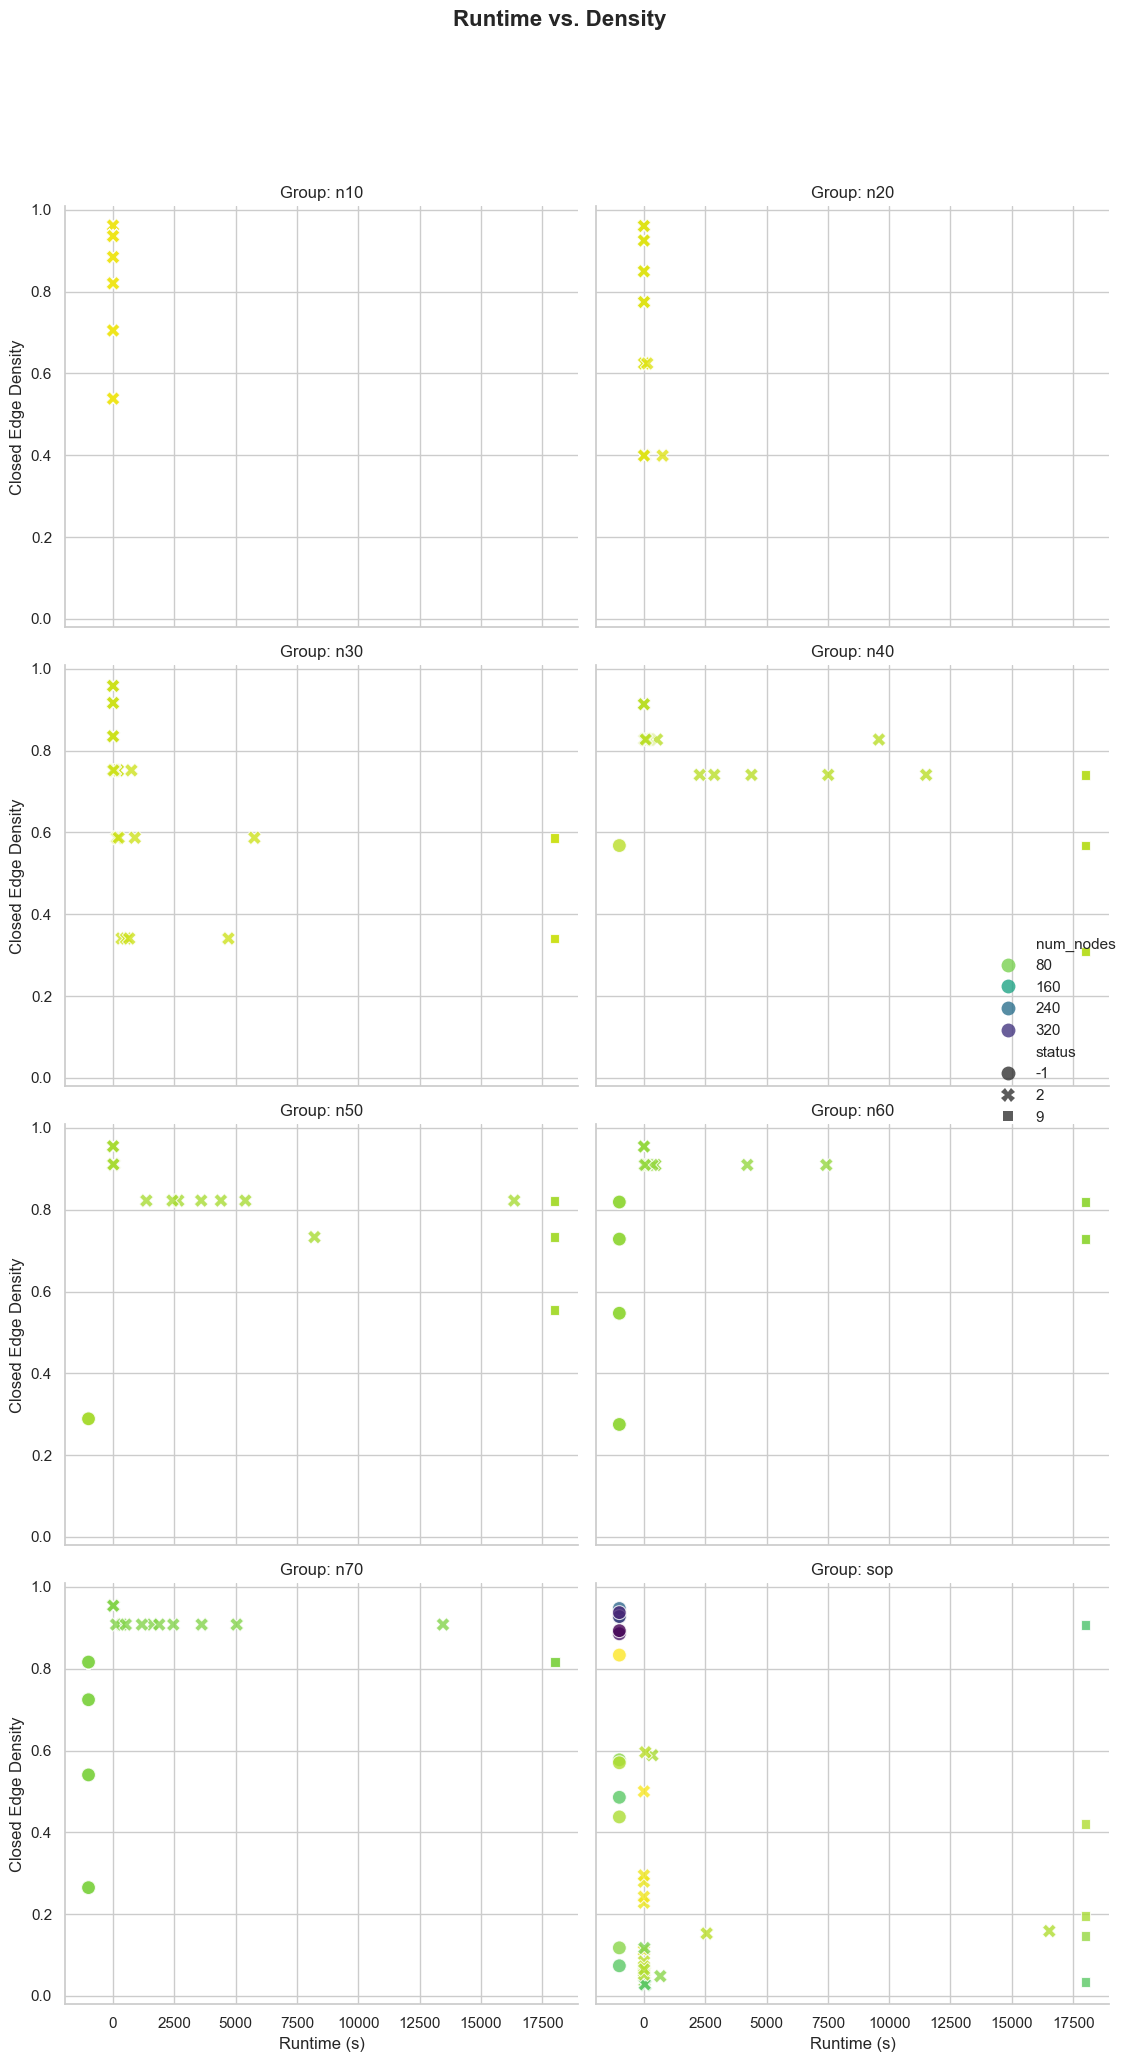

In [222]:
plot_grid_by_group(result_table, algorithm="MULTIFLOW")

Data to be plotted in grid:
shape: (450, 20)
┌────────────┬────────────┬──────────┬───────────┬───┬────────────┬───────────┬────────┬───────────┐
│ instance   ┆ algorithm  ┆ group_id ┆ num_nodes ┆ … ┆ solve_time ┆ sum_time  ┆ status ┆ runtime   │
│ ---        ┆ ---        ┆ ---      ┆ ---       ┆   ┆ ---        ┆ ---       ┆ ---    ┆ ---       │
│ str        ┆ str        ┆ str      ┆ i64       ┆   ┆ f64        ┆ f64       ┆ i64    ┆ f64       │
╞════════════╪════════════╪══════════╪═══════════╪═══╪════════════╪═══════════╪════════╪═══════════╡
│ n10o0.2-1. ┆ FEASIBILIT ┆ n10      ┆ 13        ┆ … ┆ 0.78826    ┆ 0.78826   ┆ 2      ┆ 0.78826   │
│ rcp        ┆ Y          ┆          ┆           ┆   ┆            ┆           ┆        ┆           │
│ n10o0.2-2. ┆ FEASIBILIT ┆ n10      ┆ 13        ┆ … ┆ 0.78778    ┆ 1.429612  ┆ 2      ┆ 1.429612  │
│ rcp        ┆ Y          ┆          ┆           ┆   ┆            ┆           ┆        ┆           │
│ n10o0.2-3. ┆ FEASIBILIT ┆ n10      ┆ 13     

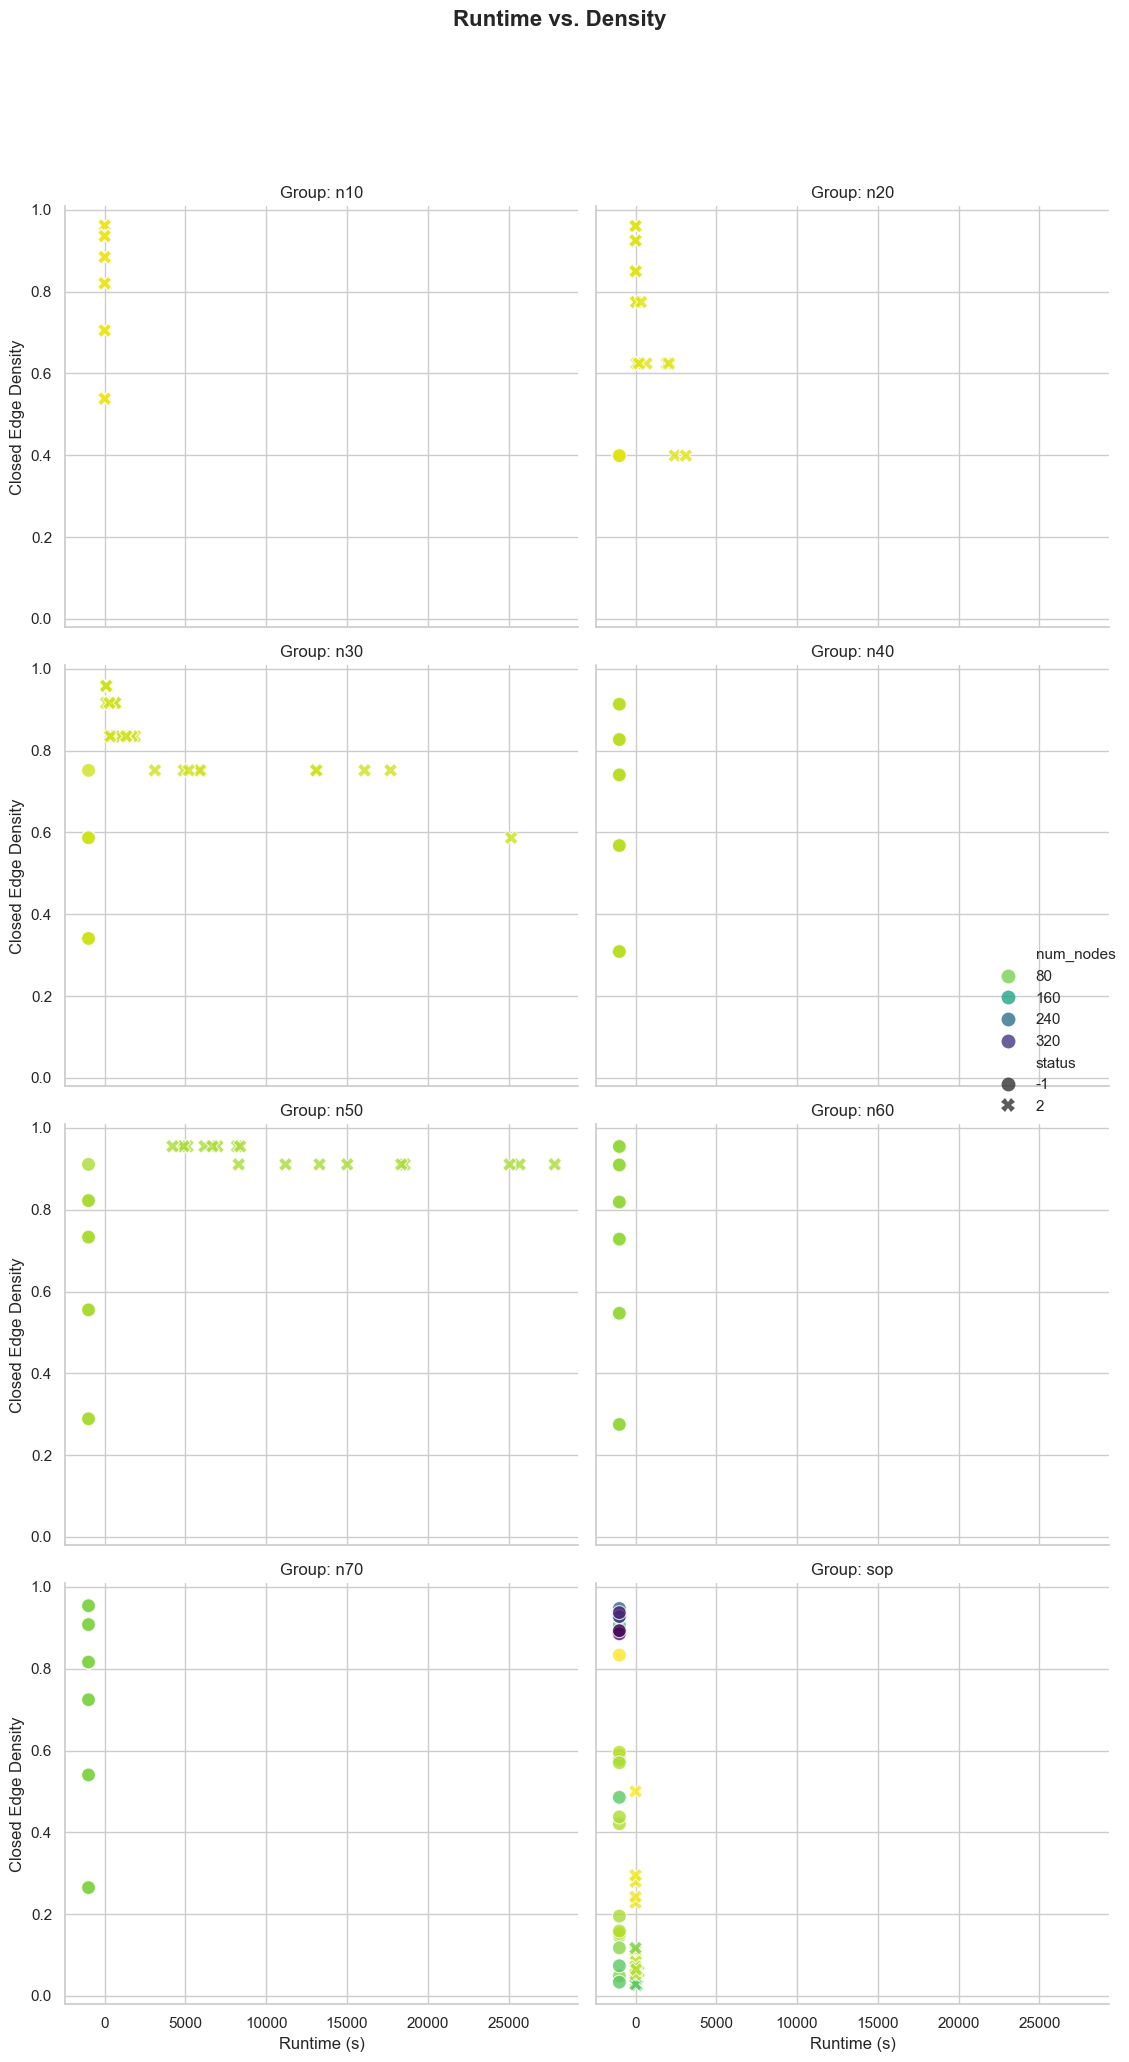

In [223]:
plot_grid_by_group(result_table, algorithm="FEASIBILITY")

Data to be plotted (with jitter):
shape: (361, 22)
┌──────────┬───────────┬───────────┬────────────┬───┬────────┬────────────┬────────────┬───────────┐
│ group_id ┆ num_nodes ┆ num_edges ┆ num_closed ┆ … ┆ status ┆ runtime    ┆ runtime_ji ┆ closed_ed │
│ ---      ┆ ---       ┆ ---       ┆ _edges     ┆   ┆ ---    ┆ ---        ┆ ttered     ┆ ge_densit │
│ str      ┆ i64       ┆ i64       ┆ ---        ┆   ┆ i64    ┆ f64        ┆ ---        ┆ y_jittere │
│          ┆           ┆           ┆ i64        ┆   ┆        ┆            ┆ f64        ┆ d         │
│          ┆           ┆           ┆            ┆   ┆        ┆            ┆            ┆ ---       │
│          ┆           ┆           ┆            ┆   ┆        ┆            ┆            ┆ f64       │
╞══════════╪═══════════╪═══════════╪════════════╪═══╪════════╪════════════╪════════════╪═══════════╡
│ n10      ┆ 13        ┆ 20        ┆ 42         ┆ … ┆ 2      ┆ 0.195699   ┆ 275.378783 ┆ 0.527245  │
│ n10      ┆ 13        ┆ 20        ┆ 42 

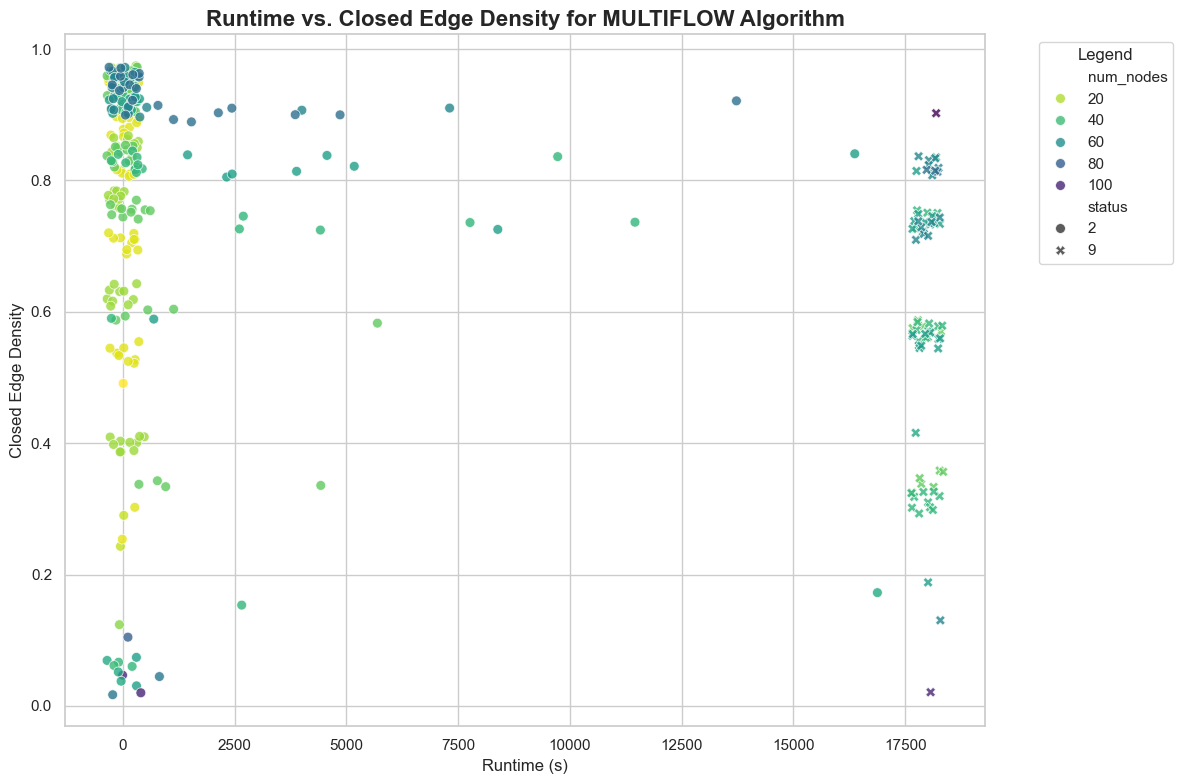

In [137]:
plot_runtime_vs_density(result_table, algorithm="MULTIFLOW")

Data to be plotted (with jitter):
shape: (361, 22)
┌──────────┬───────────┬───────────┬────────────┬───┬────────┬────────────┬────────────┬───────────┐
│ group_id ┆ num_nodes ┆ num_edges ┆ num_closed ┆ … ┆ status ┆ runtime    ┆ runtime_ji ┆ num_nodes │
│ ---      ┆ ---       ┆ ---       ┆ _edges     ┆   ┆ ---    ┆ ---        ┆ ttered     ┆ _jittered │
│ str      ┆ i64       ┆ i64       ┆ ---        ┆   ┆ i64    ┆ f64        ┆ ---        ┆ ---       │
│          ┆           ┆           ┆ i64        ┆   ┆        ┆            ┆ f64        ┆ f64       │
╞══════════╪═══════════╪═══════════╪════════════╪═══╪════════╪════════════╪════════════╪═══════════╡
│ n10      ┆ 13        ┆ 20        ┆ 42         ┆ … ┆ 2      ┆ 0.195699   ┆ 293.425726 ┆ 13.865918 │
│ n10      ┆ 13        ┆ 20        ┆ 42         ┆ … ┆ 2      ┆ 0.101355   ┆ -352.83811 ┆ 13.249331 │
│          ┆           ┆           ┆            ┆   ┆        ┆            ┆ 7          ┆           │
│ n10      ┆ 13        ┆ 20        ┆ 42 

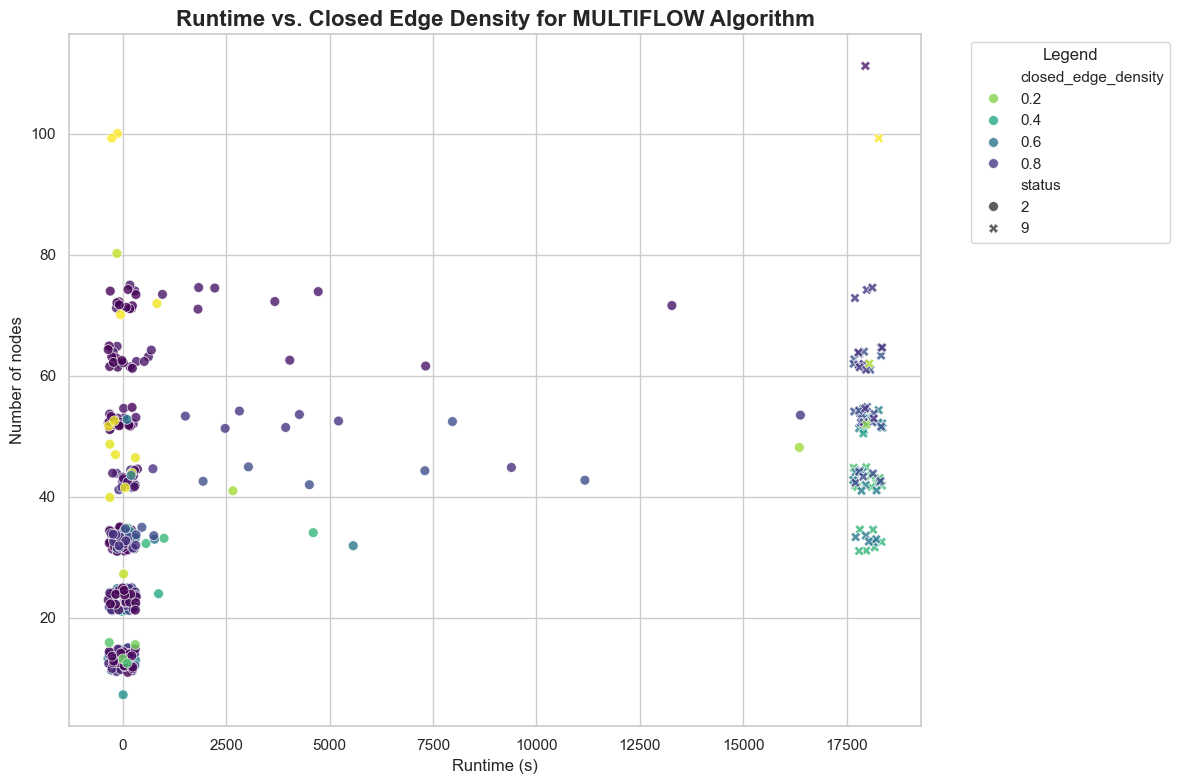

In [142]:
plot_runtime_vs_num_nodes(result_table, algorithm="MULTIFLOW")

Data to be plotted (with jitter):
shape: (187, 22)
┌──────────┬───────────┬───────────┬────────────┬───┬────────┬───────────┬────────────┬────────────┐
│ group_id ┆ num_nodes ┆ num_edges ┆ num_closed ┆ … ┆ status ┆ runtime   ┆ runtime_ji ┆ num_nodes_ │
│ ---      ┆ ---       ┆ ---       ┆ _edges     ┆   ┆ ---    ┆ ---       ┆ ttered     ┆ jittered   │
│ str      ┆ i64       ┆ i64       ┆ ---        ┆   ┆ i64    ┆ f64       ┆ ---        ┆ ---        │
│          ┆           ┆           ┆ i64        ┆   ┆        ┆           ┆ f64        ┆ f64        │
╞══════════╪═══════════╪═══════════╪════════════╪═══╪════════╪═══════════╪════════════╪════════════╡
│ n10      ┆ 13        ┆ 20        ┆ 42         ┆ … ┆ 2      ┆ 0.78826   ┆ 46.849254  ┆ 14.302758  │
│ n10      ┆ 13        ┆ 20        ┆ 42         ┆ … ┆ 2      ┆ 1.429612  ┆ 20.376061  ┆ 11.486828  │
│ n10      ┆ 13        ┆ 20        ┆ 42         ┆ … ┆ 2      ┆ 0.952894  ┆ 175.992859 ┆ 11.324523  │
│ n10      ┆ 13        ┆ 19        ┆ 42 

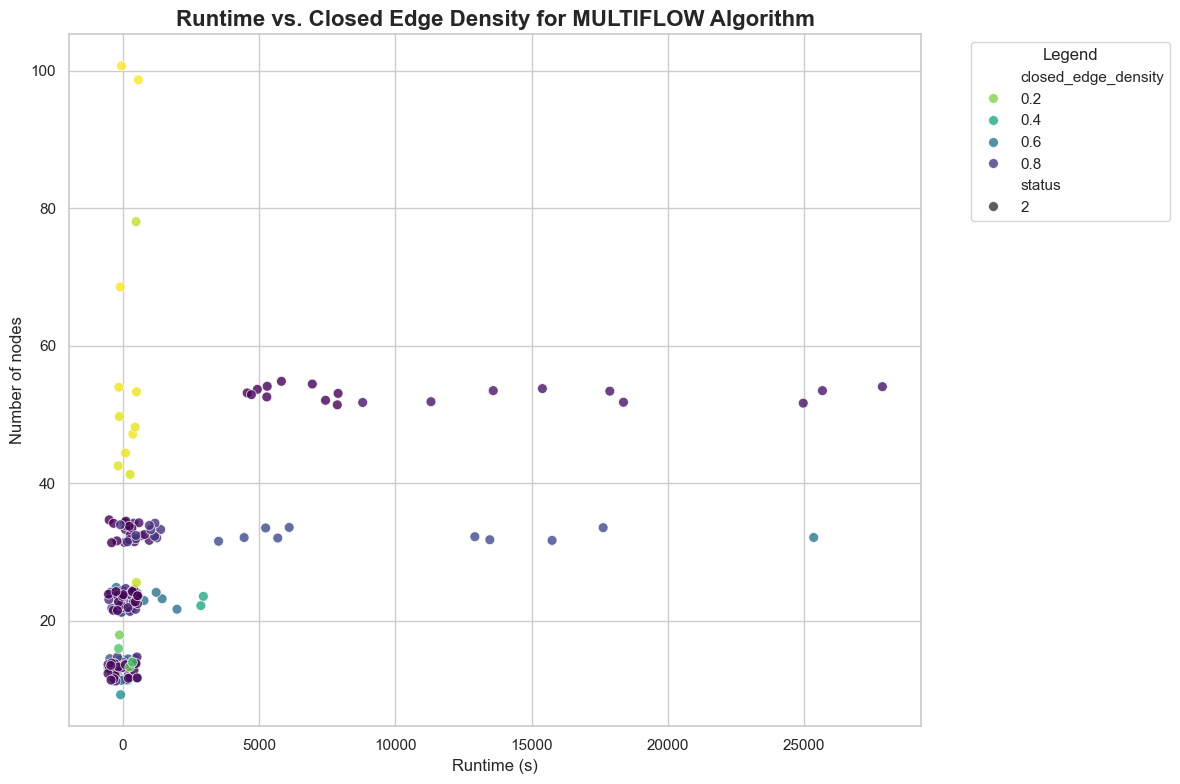

In [143]:
plot_runtime_vs_num_nodes(result_table, algorithm="FEASIBILITY")

Data to be plotted (with jitter):
shape: (187, 22)
┌──────────┬───────────┬───────────┬────────────┬───┬────────┬───────────┬────────────┬────────────┐
│ group_id ┆ num_nodes ┆ num_edges ┆ num_closed ┆ … ┆ status ┆ runtime   ┆ runtime_ji ┆ closed_edg │
│ ---      ┆ ---       ┆ ---       ┆ _edges     ┆   ┆ ---    ┆ ---       ┆ ttered     ┆ e_density_ │
│ str      ┆ i64       ┆ i64       ┆ ---        ┆   ┆ i64    ┆ f64       ┆ ---        ┆ jittered   │
│          ┆           ┆           ┆ i64        ┆   ┆        ┆           ┆ f64        ┆ ---        │
│          ┆           ┆           ┆            ┆   ┆        ┆           ┆            ┆ f64        │
╞══════════╪═══════════╪═══════════╪════════════╪═══╪════════╪═══════════╪════════════╪════════════╡
│ n10      ┆ 13        ┆ 20        ┆ 42         ┆ … ┆ 2      ┆ 0.78826   ┆ -352.10118 ┆ 0.534359   │
│          ┆           ┆           ┆            ┆   ┆        ┆           ┆ 9          ┆            │
│ n10      ┆ 13        ┆ 20        ┆ 42 

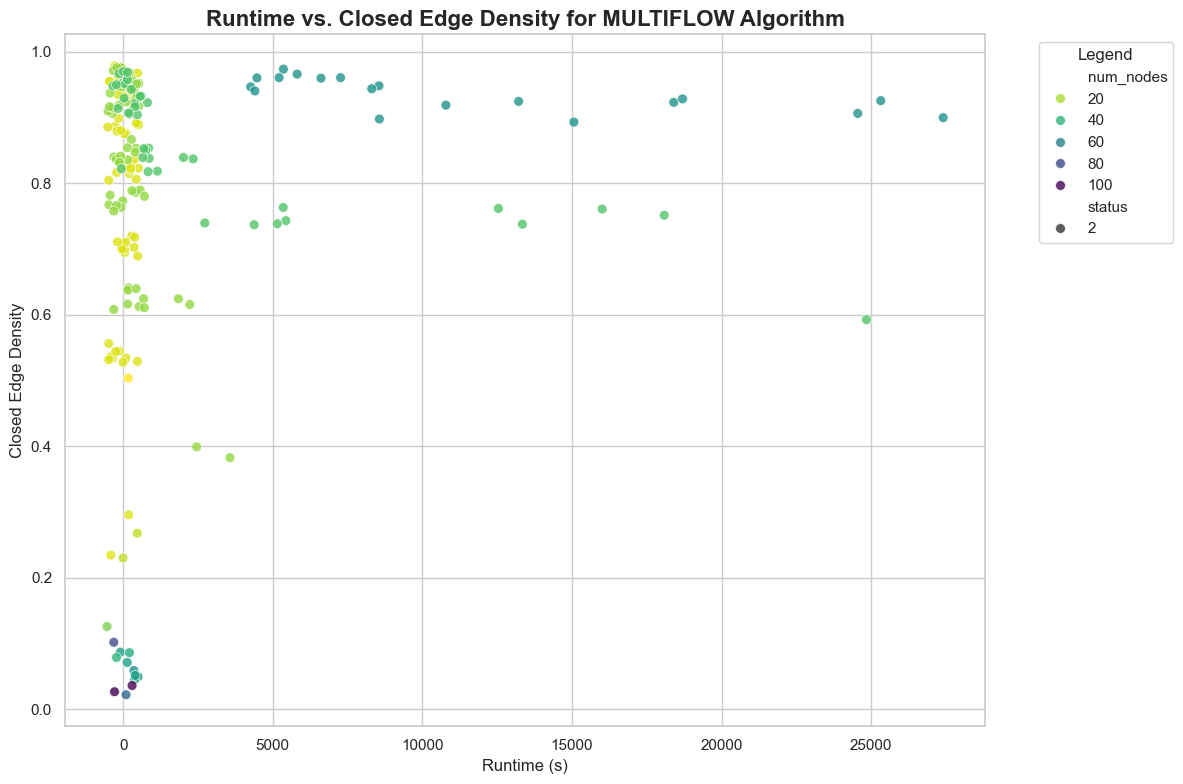

In [138]:
plot_runtime_vs_density(result_table, algorithm="FEASIBILITY")

In [120]:
result_table = result_table.with_columns((pl.col("in_degrees")
        .list.eval(pl.element().cast(pl.String))  # 1. Cast numbers in list to strings
        .list.join(", ")                          # 2. Join the strings with a separator
        .alias("in_degrees")))
result_table.write_csv("result_table.csv")

In [39]:
df_result = df_run_result.join(df_invariants, on="instance", how="left")
df_result = df_result.with_columns((pl.col("num_closed_edges") / ((pl.col("num_nodes") * (pl.col("num_nodes") - 1))/2)).alias("closed_edge_density"))
df_result = df_result.select(["instance", "algorithm", "num_nodes", "num_edges", "num_closed_edges", "closed_edge_density","nodes_indegree_gt_one", "max_in_degree", "mean_in_degree","num_jumps","runtime", "primal_bound", "dual_bound", "num_explored_nodes", "status"])
df_result.write_csv("sop_analysis.csv")

In [ ]:
# new dataset
https://data.mendeley.com/datasets/ddrwjw65ms/1
https://data.mendeley.com/datasets/nkdmg5dgpv/1
https://data.mendeley.com/datasets/ttjswzhb5v/1
https://data.mendeley.com/datasets/tsp5gfd559/1